### TODO

- IRF
- Słabe powiazanie trendu stopy procentowej i wzrostu dywidendy - może chodzić o konsumpcję
- obliczyć dla prior trend covariance 1%
- duze przedziały trendów - moze dodac oczekiwania
- duży przedział trendu erp, choć stabilny - może dododać rv, moze zawezic prior
- dodać SV
- dodac wzrost gdp/konsumpcji per capita`
- zrobić symulację

In [1]:
import Pkg
Pkg.activate("../.")


  Activating project at `~/projects/MacroFinanceScenarios`


In [2]:
using Revise

In [3]:
includet("../src/TCVAR/TCVAR.jl")

In [4]:
using .TCVAR
using DataFrames, XLSX, TimeSeries
using StatsBase
using LinearAlgebra
using Distributions
using Plots


In [5]:
df = DataFrame(XLSX.readtable("../data/ie_data.xlsx", "Data2"))
df.Date = Date.(df.Date)

data = TimeArray(df[!,[:Date, :CPI, :TBILL, Symbol("Rate GS10"), :Real_Price, Symbol(" Real_Dividend")]]; timestamp=:Date)
data = collapse(data, Dates.quarter, first)


369×5 TimeArray{Float64, 2, Date, Matrix{Float64}} 1934-01-01 to 2026-01-01
┌────────────┬─────────┬───────┬───────────┬────────────┬────────────────┐
│            │ CPI     │ TBILL │ Rate GS10 │ Real_Price │  Real_Dividend │
├────────────┼─────────┼───────┼───────────┼────────────┼────────────────┤
│ 1934-01-01 │    13.2 │  0.72 │      3.12 │    267.592 │        11.1912 │
│ 1934-04-01 │    13.3 │  0.15 │    3.0375 │    275.155 │          11.17 │
│ 1934-07-01 │    13.4 │  0.15 │     2.955 │    236.839 │        11.1492 │
│ 1934-10-01 │    13.5 │  0.27 │    2.8725 │    222.176 │        11.1286 │
│ 1935-01-01 │    13.6 │   0.2 │      2.79 │    228.181 │        11.0887 │
│ 1935-04-01 │    13.8 │  0.15 │     2.755 │    219.531 │        10.8471 │
│ 1935-07-01 │    13.7 │  0.15 │      2.72 │    260.517 │        10.7631 │
│ 1935-10-01 │    13.7 │   0.2 │     2.685 │    291.583 │        11.0078 │
│ 1936-01-01 │    13.8 │   0.2 │      2.65 │    334.154 │        11.6565 │
│ 1936-04-01 │    13.7 │

In [6]:
colnames(data)

5-element Vector{Symbol}:
 :CPI
 :TBILL
 Symbol("Rate GS10")
 :Real_Price
 Symbol(" Real_Dividend")

In [7]:
cpi = (log.(data[:CPI]) .- log.(lag(data[:CPI], 4))) .* 100
g = (log.(data[Symbol(" Real_Dividend")]) .- log.(lag(data[Symbol(" Real_Dividend")], 4))) .* 100
dy = (data[Symbol(" Real_Dividend")] ./ data[:Real_Price]) .* 100

data = merge(cpi, data[:TBILL], data[Symbol("Rate GS10")], g, dy)
TimeSeries.rename!(data, [:CPI, :TBILL, :GS10, :G, :DY])

365×5 TimeArray{Float64, 2, Date, Matrix{Float64}} 1935-01-01 to 2026-01-01
┌────────────┬───────────┬───────┬────────┬───────────┬─────────┐
│            │ CPI       │ TBILL │ GS10   │ G         │ DY      │
├────────────┼───────────┼───────┼────────┼───────────┼─────────┤
│ 1935-01-01 │    2.9853 │   0.2 │   2.79 │ -0.919664 │ 4.85961 │
│ 1935-04-01 │   3.69046 │  0.15 │  2.755 │  -2.93379 │ 4.94101 │
│ 1935-07-01 │   2.21411 │  0.15 │   2.72 │  -3.52368 │ 4.13146 │
│ 1935-10-01 │   1.47061 │   0.2 │  2.685 │  -1.09212 │ 3.77517 │
│ 1936-01-01 │   1.45988 │   0.2 │   2.65 │   4.99397 │ 3.48837 │
│ 1936-04-01 │ -0.727276 │   0.2 │ 2.6575 │   15.2858 │ 3.47222 │
│ 1936-07-01 │    1.4493 │  0.15 │  2.665 │   24.4369 │ 3.66324 │
│ 1936-10-01 │   2.16615 │  0.13 │ 2.6725 │   34.0922 │  3.8287 │
│ 1937-01-01 │   2.15062 │  0.17 │   2.68 │   39.7752 │ 4.15009 │
│ 1937-04-01 │   4.28637 │  0.56 │   2.65 │   36.9032 │ 4.58554 │
│ 1937-07-01 │   4.22598 │  0.28 │   2.62 │   31.7335 │ 4.92859 │


In [8]:
presample, y = data[Date(1954,01,01):Date(1959,12,31)], data[Date(1960,01,01):Date(2025,12,31)]

#display(presample)
#display(data)

term = presample[:GS10] .- presample[:TBILL]
rs = presample[:TBILL] .- presample[:CPI]
erp = presample[:DY] .+ presample[:G] .- rs

[mean(values(presample[:CPI])), mean(values(rs)), mean(values(term)), mean(values(presample[:G])), mean(values(erp))]

5-element Vector{Float64}:
 1.4320577437307191
 0.807942256269281
 1.0120833333333332
 2.4147391777108527
 5.57664431134042

In [9]:
pre_std = [std(values(presample[:CPI])), std(values(rs)), std(values(presample[:TBILL])), std(values(term)), std(values(presample[:GS10])), std(values(presample[:G])), std(values(erp)), std(values(presample[:DY]))]
pre_std .^ 2

8-element Vector{Float64}:
  2.0120107383475285
  1.8127801948409297
  0.9315304347826088
  0.2548259057971014
  0.4356259057971014
 28.90333053101063
 24.830690333341312
  0.4444848410008812

In [41]:
n = 5 #number of observatin variables
nt = 5 #number of trends
p=4

# Minnesota prior for the cycle VAR (mean-zero cycle => white-noise prior, δ = 0).
# ψ is the prior scale of diag(Σc); with d = n+2 it equals the prior mean of diag(Σc).
cycle_prior = MinnesotaPrior(.2, n, p, [2., 1., .1, 25., 1], n + 2; δ = zeros(n))

# prior mean of the cycle covariance, used for initial states / simulation below
cycle_covariance_mean = Matrix(cycle_prior.Ψ) / (cycle_prior.d - n - 1)

priors = (
        initial_trend_mean = [2., .5, 1., 2., 5.],
        initial_cycle_mean = zeros(n),
        initial_trend_covariance = diagm(fill(1,nt)),
        trend_covariance_df = 100,
        trend_covariance_mean = diagm([2., 1., 1., 2., 1.].^2 ./ 400),
        )

LoadError: UndefVarError: `MinnesotaPrior` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [20]:
Σ_prior, β_prior, c0_prior = var_priors(.2, 2, [2., 1., .1, 25., 1]; δ = [0,0,0,0,0] )

c0_prior.μ

10-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [33]:
Σ_prior, β_prior, c0_prior = var_priors(.2, 2, [2., 1., .1, 25., 1]; δ = [0,0,0,0,0] )

priors = (
    initial_trend = MvNormal([2., .5, 1., 2., 5.], diagm(ones(5))),
    initial_cycle = c0_prior,
    trend_covariance = InverseWishart(100, diagm([2., 1., 1., 2., 1.].^2 ./ 400)),
    cycle_covariance = Σ_prior,
    cycle_β = β_prior
)

(initial_trend = FullNormal(
dim: 5
μ: [2.0, 0.5, 1.0, 2.0, 5.0]
Σ: [1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0]
)
, initial_cycle = FullNormal(
dim: 10
μ: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Σ: [2.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 25.0 0.0; 0.0 0.0 … 0.0 1.0]
)
, trend_covariance = InverseWishart{Float64, PDMats.PDMat{Float64, Matrix{Float64}}}(
df: 100.0
Ψ: [0.01 0.0 … 0.0 0.0; 0.0 0.0025 … 0.0 0.0; … ; 0.0 0.0 … 0.01 0.0; 0.0 0.0 … 0.0 0.0025]
)
, cycle_covariance = InverseWishart{Float64, PDMats.PDMat{Float64, Matrix{Float64}}}(
df: 7.0
Ψ: [2.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 25.0 0.0; 0.0 0.0 … 0.0 1.0]
)
, cycle_β = MinnesotaPrior{Float64}(5, 2, 10, 0.2, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Diagonal([0.020000000000000004, 0.04000000000000001, 0.4000000000000001, 0.0016000000000000003, 0.04000000000000001, 0.005000000000000001, 0.010000000000000002, 0.100

# osobny trend term i erp




In [11]:
observation_trend_mapping  = [1 0 0 0 0
                              1 1 0 0 0
                              1 1 1 0 0
                              0 0 0 1 0
                              0 1 0 -1 1 ]

model = TCVAR.TCVAR(observation_trend_mapping, priors, cycle_prior; variable_names=String.(colnames(y)), trend_names=["pi", "r", "term", "d", "erp"] )

Main.TCVAR.TCVAR(Main.TCVAR.StateSpaceModel([1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0], [1.0 0.0 … 0.0 0.0; 1.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 1.0 … 0.0 1.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [2.220446049250313e-16 0.0 … 0.0 0.0; 0.0 2.220446049250313e-16 … 0.0 0.0; … ; 0.0 0.0 … 2.220446049250313e-16 0.0; 0.0 0.0 … 0.0 2.220446049250313e-16]), (initial_trend_mean = [2.0, 0.5, 1.0, 2.0, 5.0], initial_cycle_mean = [0.0, 0.0, 0.0, 0.0, 0.0], initial_trend_covariance = [1 0 … 0 0; 0 1 … 0 0; … ; 0 0 … 1 0; 0 0 … 0 1], trend_covariance_df = 100, trend_covariance_mean = [0.01 0.0 … 0.0 0.0; 0.0 0.0025 … 0.0 0.0; … ; 0.0 0.0 … 0.01 0.0; 0.0 0.0 … 0.0 0.0025], cycle = MinnesotaPrior{Float64}(5, 4, 21, 0.2, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Diagonal([0.02000000000000000

In [12]:
result = TCVAR.gibbs_sampler(model, convert(Matrix{Union{Missing, Float64}}, values(y)); burnin = 1_000, n_samples = 1_000, thin=2, logging=true)

result

Gibbs sampler: draw 2000 of 2000


TCVarResult(Main.TCVAR.TCVAR(Main.TCVAR.StateSpaceModel([1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0], [1.0 0.0 … 0.0 0.0; 1.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 1.0 … 0.0 1.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [2.220446049250313e-16 0.0 … 0.0 0.0; 0.0 2.220446049250313e-16 … 0.0 0.0; … ; 0.0 0.0 … 2.220446049250313e-16 0.0; 0.0 0.0 … 0.0 2.220446049250313e-16]), (initial_trend_mean = [2.0, 0.5, 1.0, 2.0, 5.0], initial_cycle_mean = [0.0, 0.0, 0.0, 0.0, 0.0], initial_trend_covariance = [1 0 … 0 0; 0 1 … 0 0; … ; 0 0 … 1 0; 0 0 … 0 1], trend_covariance_df = 100, trend_covariance_mean = [0.01 0.0 … 0.0 0.0; 0.0 0.0025 … 0.0 0.0; … ; 0.0 0.0 … 0.01 0.0; 0.0 0.0 … 0.0 0.0025], cycle = MinnesotaPrior{Float64}(5, 4, 21, 0.2, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Diagonal([0.02000

In [13]:
_, scenarios = simulate_scenarios(result, 1000, 100)

([2.113319166666045 2.010293652117465 … 4.32496628135257 4.302965884364363; 2.113319166666045 2.296419203661474 … 2.934764595528565 2.9531034536445953; … ; 2.113319166666045 1.9508396371603025 … 1.3869791372075306 1.366134794362966; 2.113319166666045 2.3497125936425873 … 4.979061725527571 4.966690633329546;;; 0.059650528294893666 0.025050512918507024 … -0.22407535783237154 -0.20890547813655536; 0.059650528294893666 0.09952505264164302 … 0.3719690325393204 0.41075478660787; … ; 0.059650528294893666 0.09780802025462704 … 0.5156005844585314 0.4543959176180333; 0.059650528294893666 0.11473081563016477 … 0.8563337010511894 0.9911863618825498;;; 0.9256992097813894 0.9132136817269231 … 1.0799602648884483 1.038446385548165; 0.9256992097813894 0.8073079233462368 … 1.0719635754467791 1.1186873175029912; … ; 0.9256992097813894 0.8819825500558207 … 0.04686583490238785 0.10615902307766537; 0.9256992097813894 0.8723768349085999 … 1.408048424995411 1.41899103377083;;; … ;;; 0.9613551398132599 0.43700

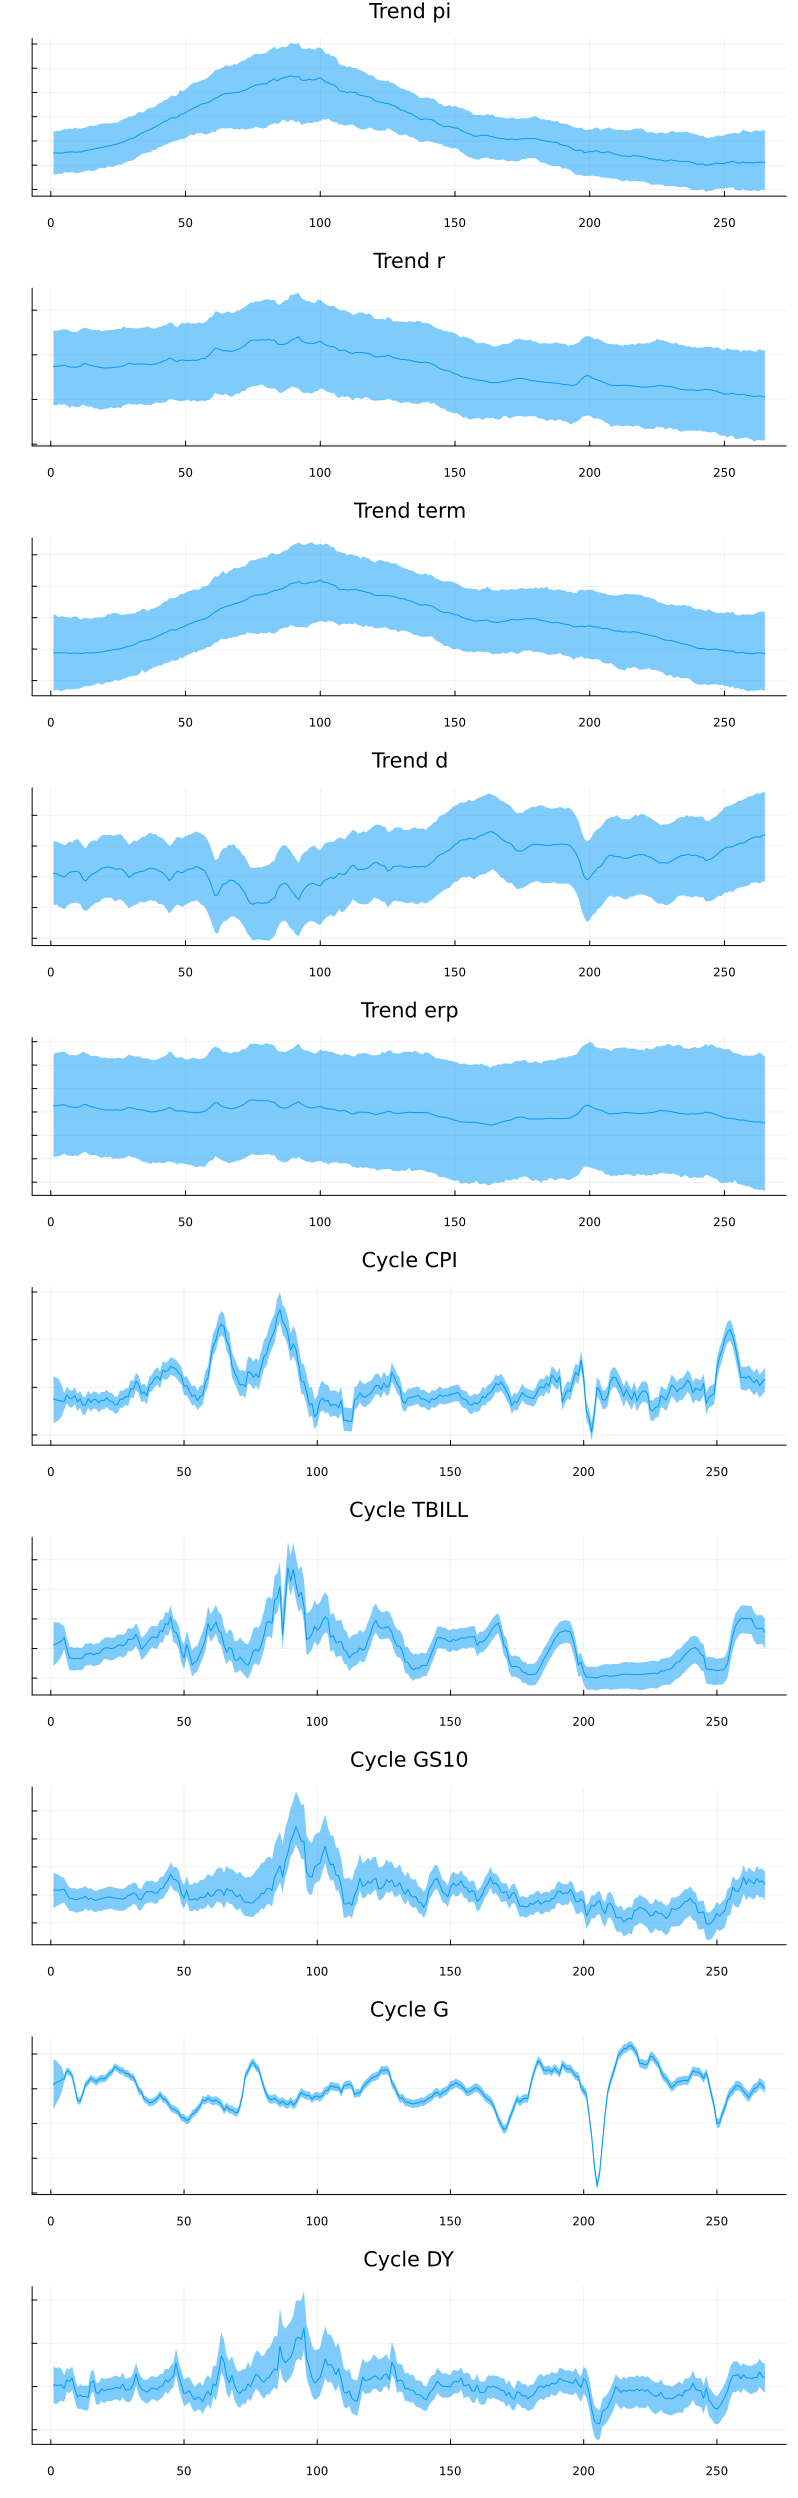

In [14]:
plot_states(result)

In [15]:
periods = [1,5,10,25]
scenarios = scenarios[:,4 .* periods,:]


1000×4×5 Array{Float64, 3}:
[:, :, 1] =
  2.65785    2.40377     3.65581    5.41274
  2.02735   -0.0690156   4.09351    4.15973
  3.52029   -0.14932     0.110798   0.571786
  3.7839     1.781       2.33632   -1.19777
  3.69368    2.00364     2.03183    1.08271
  3.52656    1.90253     4.57571   -0.105803
  4.27802    0.971806    1.06774    6.27347
  3.12307    0.717161   -0.246396  -0.466676
  1.89393    0.420321    3.43737    2.58954
 -0.685569   0.926289   -2.26229   -1.35712
  2.44569    3.65728     4.7923     3.09188
  0.677738   2.33953     0.106107   4.90434
  3.39698    5.24143     1.47346    2.83765
  ⋮                                
  2.47713   -0.391136   -1.28479    1.36009
  2.55276    2.09211     2.93922    1.04459
  0.208622  -2.20696     2.03584    2.27688
 -1.1329     4.3978      5.39589    5.24403
  3.09746    4.97047     3.58178    4.19459
  3.6022     0.0199461   5.50994    1.7215
  2.65211    2.45859     2.50537    4.81808
  1.74133    0.43654    -1.66521    4.1645

In [16]:
scenarios[:,:,5]

1000×4 Matrix{Float64}:
 0.664297   0.794833    0.461719   -0.664887
 1.13117    0.131578    1.29409    -0.20384
 1.48943    1.33558     1.19694     1.60397
 1.40134   -0.0312239  -0.0154929   0.575247
 1.06768    1.3199      1.54148     4.9683
 0.933781   0.273523    1.46733    -0.337274
 1.42862    0.724393    0.60443     1.01805
 1.38497    0.876719    1.22241     2.47159
 1.61008    1.45619     2.10527     1.97985
 1.18926    1.25411     1.50512    -0.333064
 1.19503    1.2514      2.38754     0.734968
 1.3075     1.32983     1.65013     0.0186638
 1.61516    2.84279     2.42646     2.88205
 ⋮                                 
 1.11376    1.33334    -0.0646098  -0.740958
 1.41129    1.91129     1.75313     2.20609
 0.950646   0.297462    1.49483     1.70841
 0.790344   0.230701    1.35276     1.4803
 1.14976    0.899571    0.354972    2.76698
 1.02568    1.70112     1.83202     1.30323
 1.37202    0.821058    0.272204    0.193365
 0.941507   1.20919     0.321178    1.84277
 1.33094 

In [17]:
scenarios 
print_scenarios_percentiles(scenarios[:,:,5], [.05, .25, .5, .75, .95], string.([periods]), "dy")

LoadError: BoundsError: attempt to access 1-element Vector{String} at index [2]

In [ ]:
quantile(scenarios[:,1, 4], [.05, .25, .5, .75, .95])

5-element Vector{Float64}:
 -3.1014644406328267
  0.5819798316556146
  2.911738897972425
  5.3642788929419165
  8.466651800172157

In [ ]:
quantile(scenarios[:,4, 4], [.05, .25, .5, .75, .95])

5-element Vector{Float64}:
 -4.694398694684559
 -0.2830801180800763
  3.143976842196734
  6.316016435083912
 10.95094575285243

In [ ]:
quantile(scenarios[:,1, 5], [.05, .25, .5, .75, .95])

5-element Vector{Float64}:
 0.6132559114104854
 0.8927698332673887
 1.1262082792425252
 1.3406810770629738
 1.6660288404572334

In [ ]:
quantile(scenarios[:,4, 5], [.05, .25, .5, .75, .95])

5-element Vector{Float64}:
 -1.6285232687000615
 -0.0554899963670739
  1.0220525226940942
  1.9930559816110753
  3.5707240070510973

In [ ]:
using FlexiChains

In [ ]:
mean(result.params[@varname(β)])


20×5 Matrix{Float64}:
 -0.0310138   -0.00788563    0.00877935   -0.0847153   0.00101755
 -0.0267791   -0.0309496     0.00315897   -0.0890831   0.0026929
 -0.216911    -0.0790433    -0.0762993     0.0588115  -0.00426492
 -0.00381854  -0.0014958    -0.00119207   -0.036026    0.000292509
 -0.00556105   0.0050294     0.00241241   -0.0271663   3.97301e-5
 -0.0122441    0.0101261     0.0131591    -0.0620887   0.00441419
  0.039199     0.0407481     0.0194148    -0.134096    0.00291199
 -0.033528     0.0160367    -0.0175382     0.157833    0.0113014
 -0.00684355  -0.00157296   -0.0019683    -0.0380824   0.000632465
 -0.00456509  -0.00595447    0.00055894   -0.0957912  -0.00195074
  0.0743025    0.0271091     0.0158067     0.0157588   0.0131422
  0.0618852    0.0566078     0.00206758   -0.115789    0.00187985
 -0.224797    -0.143357      0.000387024   0.234992    0.0528268
 -0.0073202    0.000655773  -0.00129684    0.0377423   0.00265785
 -0.00413073   0.01012       0.00883611   -0.156562    0

In [ ]:
update_

In [ ]:
st = summarystats(result.params; split_varnames=false)
st[@varname(β)]


┌ 9-element DimArray{Union{Missing, Matrix{Float64}}, 1} Parameter(β) ┐
├─────────────────────────────────────────────────────────────── dims ┤
  ↓ stat Categorical{Symbol} [:mean, …, :q95] Unordered
└─────────────────────────────────────────────────────────────────────┘
 :mean      …  [-0.0326108 -0.00973868 … -0.0618596 -0.000530755; -0.0227295 -0.02572 … -0.111505 0.00110147; … ; -0.00685747 0.016549 … 0.900498 0.0174588; -0.0239453 -0.243792 … -0.101174 0.059953]
 :std          [0.0230718 0.0233048 … 0.0670776 0.00501924; 0.0350831 0.0308478 … 0.0864586 0.00736583; … ; 0.0147595 0.0123081 … 0.0374925 0.00566988; 0.149643 0.16487 … 0.418175 0.0343923]
 :mcse         missing
 :ess_bulk     missing
 :ess_tail     missing
 :rhat      …  missing
 :q5           missing
 :q50          missing
 :q95          missing

In [ ]:
plot(result.params)

┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.

┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.

LoadError: The backend must not support the series type Val{:density}, and there isn't a series recipe defined.

In [ ]:
using FlexiChains: collapse, StatsBase

In [ ]:
collapse(result.params, [
    mean,    
    rhat
])

╭─FlexiSummary (2 statistics) ─────────────────────────────────────────────────╮
│   iter    collapsed                                                          │
│   chain   collapsed                                                          │
│ ↓ stat  = [mean, rhat]                                                       │
│                                                                              │
│ Parameters (150) ── VarName                                                  │
│  Float64  Στ[1, 1], Στ[2, 1], Στ[3, 1], Στ[4, 1], Στ[5, 1], Στ[1, 2],        │
│           Στ[2, 2], Στ[3, 2], Στ[4, 2], Στ[5, 2], Στ[1, 3], Στ[2, 3],        │
│           Στ[3, 3], Στ[4, 3], Στ[5, 3], Στ[1, 4], Στ[2, 4], Στ[3, 4],        │
│           Στ[4, 4], Στ[5, 4], Στ[1, 5], Στ[2, 5], Στ[3, 5], Στ[4, 5],        │
│           Στ[5, 5], β[1, 1], β[2, 1], β[3, 1], β[4, 1], β[5, 1], β[6, 1],    │
│           β[7, 1], β[8, 1], β[9, 1], β[10, 1], β[11, 1], β[12, 1], β[13, 1], │
│           β[14, 1], β[15, 

In [ ]:
st = collapse(result.params, [
    mean, 
    median,   
    (:q5, x -> quantile(x, 0.05)),
    (:q95, x -> quantile(x, 0.95)),
])

df = DataFrame(st)




Row,param,mean,median,q5,q95
,VarName…,Float64,Float64,Float64,Float64
1,"Στ[1, 1]",0.0135938,0.0131971,0.0103605,0.0169514
2,"Στ[2, 1]",0.000735424,0.000692465,-0.00051737,0.00184568
3,"Στ[3, 1]",0.000846064,0.000805372,-0.000224552,0.00202874
4,"Στ[4, 1]",-0.000385248,-0.000180114,-0.0028728,0.00209626
5,"Στ[5, 1]",9.41529e-5,4.42672e-5,-0.00112191,0.00112373
6,"Στ[1, 2]",0.000735424,0.000692465,-0.00051737,0.00184568
7,"Στ[2, 2]",0.00312881,0.00314994,0.00254932,0.00384191
8,"Στ[3, 2]",0.000289535,0.000204229,-0.000174946,0.00099728
9,"Στ[4, 2]",-0.000719014,-0.000625003,-0.0020874,0.000152915


In [ ]:
filter(:param => vn -> vn isa VarName{:β}, df)

Row,param,mean,median,q5,q95
,VarName…,Float64,Float64,Float64,Float64
1,"β[1, 1]",-0.0326108,-0.0334871,-0.0689642,0.00429651
2,"β[2, 1]",-0.0227295,-0.01864,-0.0743543,0.0317006
3,"β[3, 1]",-0.212897,-0.215883,-0.333707,-0.0834485
4,"β[4, 1]",-0.00425942,-0.00427183,-0.0147086,0.00770301
5,"β[5, 1]",-0.00885678,-0.0105969,-0.0611433,0.0406432
6,"β[6, 1]",-0.00786425,-0.0112174,-0.0603452,0.0534551
7,"β[7, 1]",0.0390191,0.0423465,-0.0328906,0.108178
8,"β[8, 1]",0.00633372,0.00121115,-0.147434,0.155583
9,"β[9, 1]",-0.00756926,-0.00844159,-0.023432,0.00577286


In [ ]:
subset(df,:param => vn -> vn isa VarName{:β})

LoadError: ArgumentError: function passed to `subset`/`subset!` returned value of type `Bool` while it must return an `AbstractVector` when subsetting a data frame to ensure common mistakes in code are caught. Please report an issue if you find this restriction inconvenient.

In [ ]:
df[!,:param] isa VarName{:β}

false

In [ ]:
arr = rand(10, 4, 6)   # 10 iterations, 4 chains, 6 (scalar) parameters

names = (
    FlexiChains.Parameter(:x),            # Scalar
    Parameter(:y),            # Scalar
    Parameter(:z) => (2, 2),   # Matrix
)

chn = FlexiChain{Symbol}(arr, names)

╭─FlexiChain (10 iterations, 4 chains) ────────────────────────────────────────╮
│ ↓ iter  = 1:10                                                               │
│ → chain = 1:4                                                                │
│                                                                              │
│ Parameters (3) ── Symbol                                                     │
│  Float64          x, y                                                       │
│  Matrix{Float64}  z (2, 2)                                                   │
│                                                                              │
│ Extras (0)                                                                   │
│  (none)                                                                      │
╰──────────────────────────────────────────────────────────────────────────────╯

In [ ]:
@varname(x[1,1])

LoadError: LoadError: UndefVarError: `@varname` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at In[1]:1

In [ ]:
st = summarystats(chn)

st[Symbol("z")]


LoadError: KeyError: key :z not found

1 st version

Gibbs sampler: draw 2000 of 2000
484.571342 seconds (110.89 M allocations: 117.624 GiB, 20.84% gc time, 2.81% compilation time)

In [ ]:
trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95)
cycle_states_mean, cycle_states_lower, cycle_states_upper = TCVAR.compute_posterior_statistics(cycle_states_samples, credible_level=0.95)

([-1.1220219778032154 0.2612344089242257 … 1.1786003065015764 0.029516501454057514; -1.2847143958155482 0.2880620886605566 … 1.5251567298691076 0.01804882686276511; … ; 0.3363070305396464 1.7924669937241353 … 1.084017425718381 0.14930125879824777; 0.6543960000536834 1.3842466329838183 … 0.2069067831697578 0.12629549215343902], [-4.441234873717017 -2.7780084895014694 … -6.646980872377647 -0.5583329449522182; -4.017475478020171 -2.4347943694878316 … -4.992223003951775 -0.5237759594188272; … ; -1.7911570397337822 -0.5460363842141999 … -0.439845387273498 -0.37554152292931764; -1.5132105476183582 -0.9194433772669954 … -1.3366459340517785 -0.4485326409705204], [1.8984356031109295 2.894236515541099 … 8.647391529558426 0.5882269405871858; 1.614979099304112 2.7932449574198808 … 8.340758789813986 0.5397702548679945; … ; 1.9126648050197155 3.6807414917890044 … 2.820093485368939 0.5135859522606394; 2.1832422795196313 3.2962673497101678 … 1.9677731945472687 0.5290619830026615])

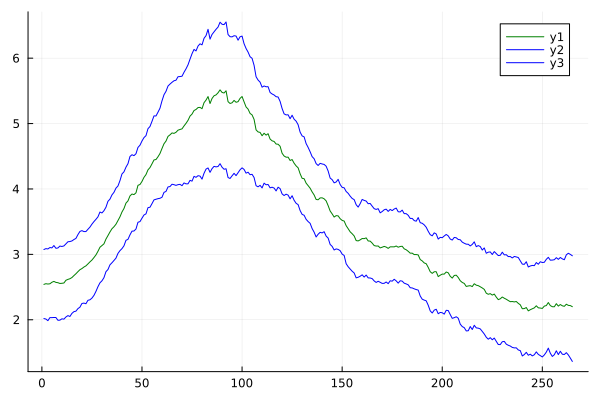

In [ ]:
st = 1
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

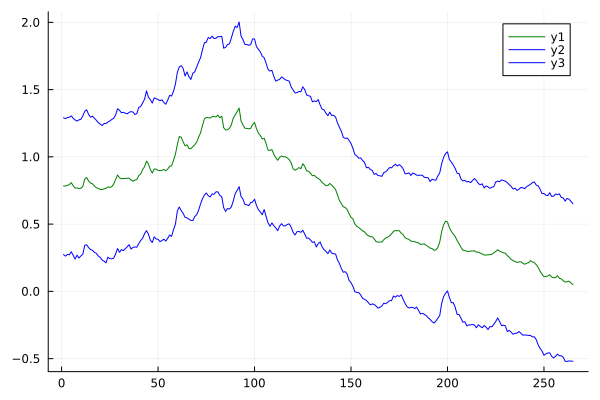

In [ ]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

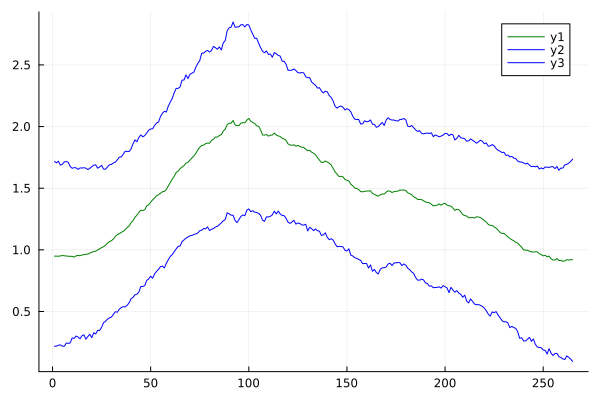

In [ ]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

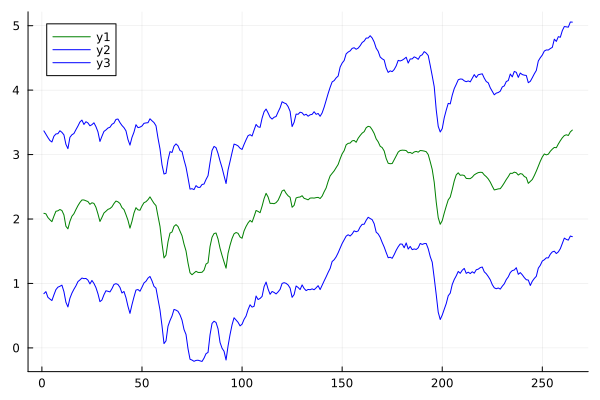

In [ ]:
st = 4
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

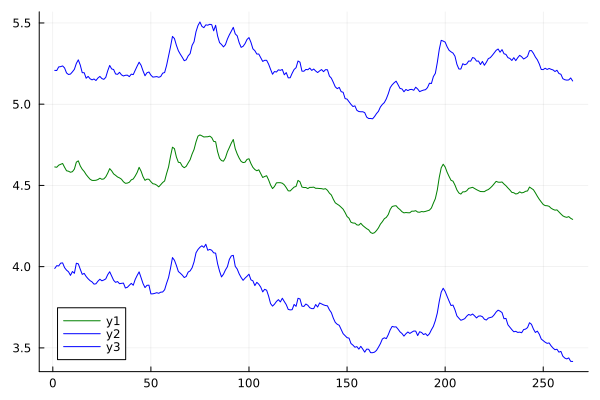

In [ ]:
st = 5
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

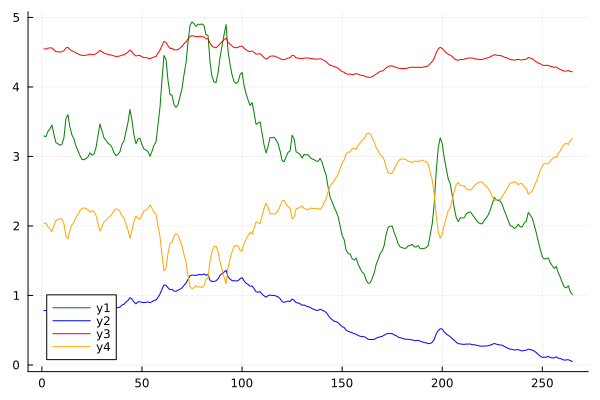

In [ ]:
plot(trend_states_mean[:,2] .+ trend_states_mean[:,5] .- trend_states_mean[:,4], color="green" )
plot!(trend_states_mean[:,2], color="blue" )
plot!(trend_states_mean[:,5], color="red" )
plot!(trend_states_mean[:,4], color="orange" )


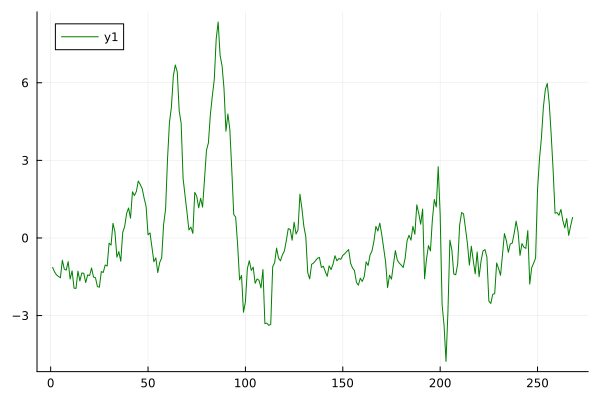

In [ ]:
st=1
plot(cycle_states_mean[:,st], color="green" )

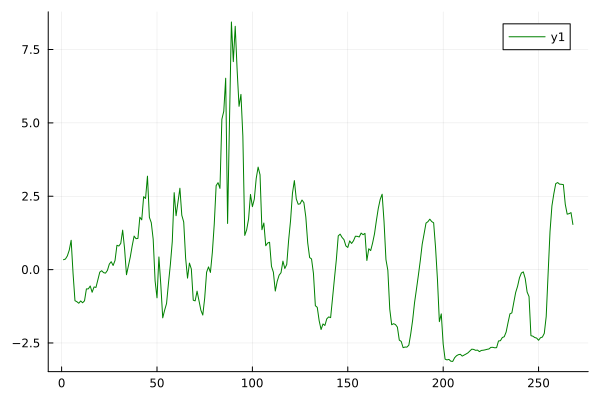

In [ ]:
st=2
plot(cycle_states_mean[:,st], color="green" )

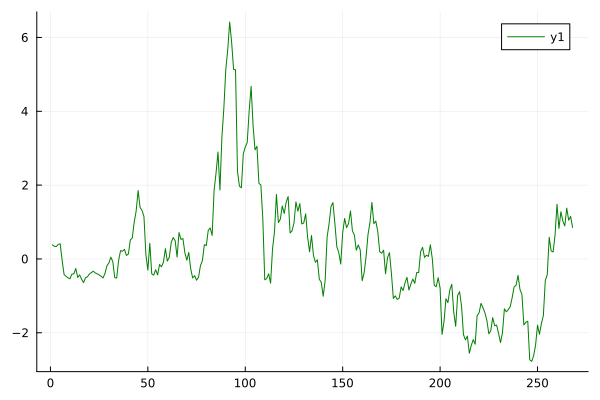

In [ ]:
st=3
plot(cycle_states_mean[:,st], color="green" )

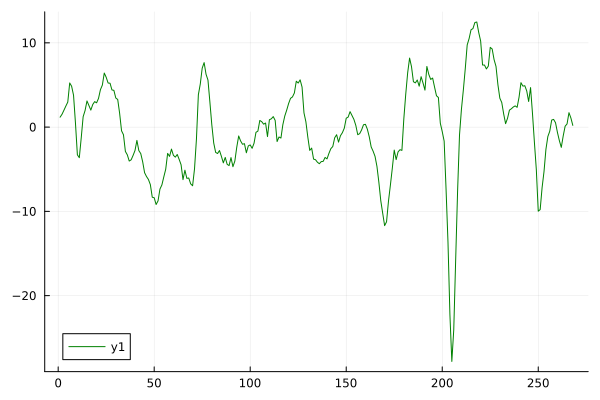

In [ ]:
st=4
plot(cycle_states_mean[:,st], color="green" )

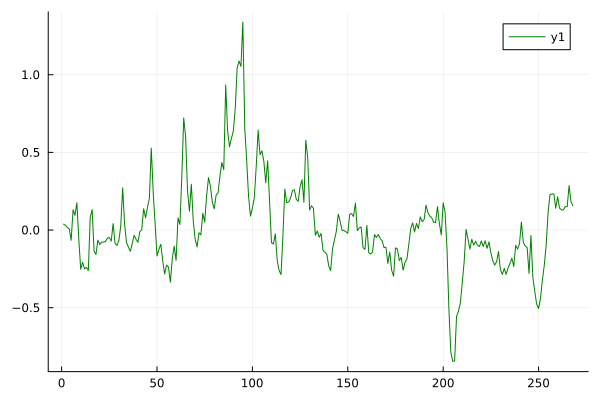

In [ ]:
st=5
plot(cycle_states_mean[:,st], color="green" )

In [ ]:
summarystats(trend_covariance_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

         Στ1    0.0136    0.0023    0.0002   109.9119   308.5591    1.0158     ⋯
         Στ2    0.0007    0.0009    0.0001    40.2138    82.3480    1.0155     ⋯
         Στ3    0.0007    0.0008    0.0001    94.6328   169.4116    1.0277     ⋯
         Στ4   -0.0012    0.0020    0.0003    35.7013   178.6375    1.0340     ⋯
         Στ5    0.0002    0.0008    0.0001   107.8692   311.3205    1.0187     ⋯
         Στ6    0.0007    0.0009    0.0001    40.2138    82.3480    1.0155     ⋯
         Στ7    0.0031    0.0005    0.0000   149.9701   217.5813    1.0007     ⋯
         Στ8    0.0003    0.0004    0.0000    78.9719   345.1458    1.0047     ⋯
         Στ9   -0.0009    0.0007    0.0001   116.1674   344.0790    1.0024     ⋯
        Στ10    0.0002    0.0003    0.0000   168.7220   240.2724    1.0004     ⋯
       

In [ ]:
summarystats(betas_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

          β1   -0.0347    0.0250    0.0011   506.7292   399.5524    0.9985     ⋯
          β2   -0.0251    0.0387    0.0026   217.7646   348.2440    1.0096     ⋯
          β3   -0.1938    0.0951    0.0094   106.9179   428.7079    1.0079     ⋯
          β4   -0.0037    0.0078    0.0004   469.6592   444.4383    0.9993     ⋯
          β5   -0.0068    0.0437    0.0021   433.4644   510.3083    1.0007     ⋯
          β6   -0.0127    0.0355    0.0016   513.8289   465.4970    1.0021     ⋯
          β7    0.0266    0.0509    0.0028   342.5224   452.0158    1.0102     ⋯
          β8    0.0138    0.1101    0.0054   423.1398   438.4716    1.0041     ⋯
          β9   -0.0043    0.0100    0.0005   415.3890   404.9553    1.0057     ⋯
         β10   -0.0071    0.0547    0.0024   506.1369   450.4360    1.0023     ⋯
       

In [ ]:
summarystats(sigmas_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

         Σc1    0.6820    0.0722    0.0126    33.4148   224.2078    1.0312     ⋯
         Σc2    0.1282    0.0407    0.0032   155.9382   342.7410    1.0146     ⋯
         Σc3    0.0914    0.0349    0.0077    23.9187   221.9159    1.0483     ⋯
         Σc4   -0.3893    0.1167    0.0060   388.1559   365.1995    1.0022     ⋯
         Σc5    0.0100    0.0130    0.0012   112.0196   300.3190    1.0019     ⋯
         Σc6    0.1282    0.0407    0.0032   155.9382   342.7410    1.0146     ⋯
         Σc7    0.5822    0.0526    0.0023   514.8109   498.0401    0.9988     ⋯
         Σc8    0.2074    0.0299    0.0019   241.3788   441.1690    0.9980     ⋯
         Σc9   -0.0405    0.1093    0.0048   539.6243   445.8232    1.0053     ⋯
        Σc10   -0.0008    0.0130    0.0018    53.7247   185.7760    1.0231     ⋯
       

In [ ]:
plot(betas_samples)

┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.

LoadError: The backend must not support the series type Val{:density}, and there isn't a series recipe defined.

In [ ]:
Σc = mean(sigmas_samples).nt.mean
Σc = reshape(Σc, n, n)
display(Σc)

β = mean(betas_samples).nt.mean
β = reshape(β, n, n*p)
display(β[:,1:n])
display(β[:,n+1:n*2])
display(β[:,2*n+1:n*3])
display(β[:,3*n+1:n*4])
Στ = mean(trend_covariance_samples).nt.mean
Στ = reshape(Στ, nt, nt)
display(cov2cor(Στ))
display(diag(Στ) .^ .5)

5×5 Matrix{Float64}:
  0.681952     0.128175      0.0913558   -0.389342    0.00997794
  0.128175     0.582174      0.207374    -0.040484   -0.000778706
  0.0913558    0.207374      0.232912    -0.0712464   0.00814837
 -0.389342    -0.040484     -0.0712464    4.78221     0.0424481
  0.00997794  -0.000778706   0.00814837   0.0424481   0.0233264

5×5 Matrix{Float64}:
 -0.0346941   -0.012707     0.0671953    0.801346    -0.00495033
 -0.0251292    0.0266145    0.052784     0.142584    -0.0231662
 -0.193781     0.0138498   -0.215101     0.0738736   -0.069069
 -0.00374928  -0.00427075  -0.00448669  -0.00446086  -7.42796e-5
 -0.00675495  -0.00711808  -0.0136585   -0.0569816   -0.000231175

5×5 Matrix{Float64}:
  0.010248      0.0305259     0.029851    0.00894982    0.0114486
  0.028502      0.0699031     0.777496    0.00515289    0.00894746
  0.00630826   -0.15001       0.298639   -0.0642234    -0.00681163
 -0.000737455  -0.000202592   0.0166825  -0.000712894  -0.00141743
  6.0308e-6    -0.00183755   -0.228898    0.00461884    0.00286286

5×5 Matrix{Float64}:
  0.012461    -0.0188502   -0.0697662  -0.0570925   0.00801833
  0.00646837   0.0768222   -0.107729   -0.111933   -0.103918
 -0.0128623    0.878279     0.056049    0.100323    0.256259
 -0.00111454  -0.00179579  -0.0340302  -0.0345753   0.0351619
  0.00772612  -0.0950274   -0.0470839  -0.0757621  -0.11566

5×5 Matrix{Float64}:
  0.185379    -0.000180259   0.0038731    0.0104728    0.0391782
 -0.0116694    0.00257715    0.00214902   6.3226e-5   -0.0064098
  0.00317311  -0.00503141    0.0103027    0.0497538    0.0805611
  0.905583     0.000139139   0.000230503  0.00257741   0.016396
 -0.0485845   -0.000772864  -0.000125547  0.0012615    0.054614

5×5 Matrix{Float64}:
  1.0         0.102009    0.108463   -0.0903584   0.0360595
  0.102009    1.0         0.0805155  -0.132181    0.0621971
  0.108463    0.0805155   1.0        -0.0665486   0.0456545
 -0.0903584  -0.132181   -0.0665486   1.0        -0.107555
  0.0360595   0.0621971   0.0456545  -0.107555    1.0

5-element Vector{Float64}:
 0.11640495558091622
 0.055973584535892594
 0.05548102719897487
 0.11879213645966126
 0.05517402304153932

In [ ]:
display(diag(Σc) .^ .5)
display(cov2cor(Σc))

display(diag(Στ) .^ .5)

5-element Vector{Float64}:
 0.8258035602412491
 0.7630035017112736
 0.4826094196456856
 2.1868262046353975
 0.1527298703039386

5×5 Matrix{Float64}:
  1.0         0.203422     0.229226   -0.215596    0.0791116
  0.203422    1.0          0.563161   -0.0242629  -0.00668226
  0.229226    0.563161     1.0        -0.0675076   0.110548
 -0.215596   -0.0242629   -0.0675076   1.0         0.127093
  0.0791116  -0.00668226   0.110548    0.127093    1.0

5-element Vector{Float64}:
 0.11640495558091622
 0.055973584535892594
 0.05548102719897487
 0.11879213645966126
 0.05517402304153932

In [ ]:
β

5×20 Matrix{Float64}:
 -0.0346941   -0.012707     0.0671953   …  0.0104728    0.0391782
 -0.0251292    0.0266145    0.052784       6.3226e-5   -0.0064098
 -0.193781     0.0138498   -0.215101       0.0497538    0.0805611
 -0.00374928  -0.00427075  -0.00448669     0.00257741   0.016396
 -0.00675495  -0.00711808  -0.0136585      0.0012615    0.054614

In [ ]:

model = tc_var(observation_trend_mapping, p = 4)
update_tc_var!(model, β, Στ, Σc)


LoadError: UndefVarError: `update_tc_var!` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
vec(permutedims(cycle_states_mean[end-3:end,:]))

20-element Vector{Float64}:
 0.7186815147774724
 1.8995172055040417
 1.3716536468825429
 0.4309948551460765
 0.1501234234069955
 0.0649048186408674
 1.9147622086834706
 1.0393965394970222
 1.7714781047483579
 0.2864409155432284
 0.4520865468958993
 1.9706834599005778
 1.1662471610757148
 1.128117062103163
 0.18090906959171155
 0.780049992503505
 1.5695949507863896
 0.8684303559758573
 0.24926974615062314
 0.15690837348085757

In [ ]:
initial_states = [trend_states_mean[end,:]; vec(permutedims(cycle_states_mean[end-3:end,:]))]

25-element Vector{Float64}:
 2.199859195209845
 0.05056466106644026
 0.9411516309236778
 3.255246252189852
 4.218059169165582
 0.7186815147774724
 1.8995172055040417
 1.3716536468825429
 0.4309948551460765
 0.1501234234069955
 0.0649048186408674
 1.9147622086834706
 1.0393965394970222
 1.7714781047483579
 0.2864409155432284
 0.4520865468958993
 1.9706834599005778
 1.1662471610757148
 1.128117062103163
 0.18090906959171155
 0.780049992503505
 1.5695949507863896
 0.8684303559758573
 0.24926974615062314
 0.15690837348085757

In [ ]:
n_samples = 2_000
T = 100
states = zeros(n_samples, T, 8)

observations = zeros(n_samples, T, n)

for s in 1:2_000
    states[s, :, :], observations[s, :, :] = TCVAR.sample(model, initial_states, T)
end


LoadError: PosDefException: matrix is not positive definite; Factorization failed.

In [ ]:
transformed_scenarios = permutedims(observations, (3, 2, 1))[[1,2],:,:] ./400
periods = [1, 5, 10, 25]
freq = 4
assets_names = ["GDP", "CPI"]
ret_in_years = cum_returns_in_periods(transformed_scenarios, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations[:,:,[3,4]] , (3, 2, 1))
freq = 4

transformed_scenarios = transformed_scenarios[:,freq:freq:end,:]

periods = [1, 5, 10, 25]


assets_names = ["ShortRate", "LongRate"]
ret_in_years = transformed_scenarios = transformed_scenarios[:,periods,:]
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
n_observations = size(model.T,1)
n_trends = 4
n_time_steps = size(data,1)
n_draws = 1000
trends_states = zeros(n_draws, n_time_steps, n_trends)

for s in 1:n_draws
    state_smoothed_samples = carter_kohn_sampler(model, values(data))
    trends_states[s,:,:] = state_smoothed_samples[:, 1:n_trends]
end

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95)

UndefVarError: UndefVarError: `model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.